<a href="https://colab.research.google.com/github/datavisionps-code/sales-data-analysis/blob/main/Churn_de_clientes_de_banco_(Bank_customer_churn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#O que queremos
Você desenvolverá um projeto de ciência de dados seguindo o passo a passo apresentado
no curso. O objetivo é que, ao final, você tenha insights profundos sobre o problema
abordado e entenda como solucioná-lo. O projeto pode focar em diversas problemáticas,
como automatização de processos, expansão da base de clientes ou qualquer outra questão
relevante.

Ao longo do desenvolvimento do projeto, você aplicará técnicas de coleta e análise de dados,
modelagem estatística, visualização de dados, e interpretação dos resultados. Assim, você será
capaz de extrair informações valiosas e formular estratégias para resolver o problema
identificado. O foco principal é obter uma compreensão clara e acionável sobre a questão em
estudo, utilizando as ferramentas e métodos aprendidos durante o curso

Churn de clientes de banco (Bank customer churn)
https://www.kaggle.com/code/esteniomariano/churn-de-clientes-de-banco-bank-customer-churn?scriptVersionId=141025344&cellId=1

#Passo a Passo do Projeto

Passo 1 - Importar Dados;

Passo 2 - Avalie a qualidade dos dados

Passo 3 - Avaliar o comportamento das variáveis

Passo 4 - Prepare os dados para uma análise mais
detalhada;

Passo 5 - Escolha um modelo e aplique-o;

Passo 6 - Refine o seu modelo;

Passo 7 – Conclusão

Análise de dados: Churn de clientes de banco
Projeto de machine learning para análise de dados e classificação de clientes que potencialmente poderão encerrar suas contas em um banco, os dados estão disponíveis na plataforma Kaggle.

O problema a ser solucionado consiste em utilizar os dados bancários dos clientes que efetuaram ou não o encerramento de suas contas para criar um modelo preditivo que irá identificar possíveis clientes que poderão ou não deixar a instituição bancária, podendo assim determinar a taxa de churn (rotatividade/perda de clientes) e com base nos perfis mapeados tomar ações para retenção dos mesmos, evitando impactos como, por exemplo, aumento de custos, queda de lucro, reputação da marca entre outros fatores sensíveis a experiência do cliente com o produto da empresa.

Demanda da análise
Analisar a correlação dos dados dos clientes.
Gerar um modelo preditivo de churn por parte de um cliente.
Tópicos da análise
1. Análise das medidas estatísticas dos dados
2. Distribuição dos valores da váriavel dependente (target)
3. Distribuição dos dados entre as variáveis independentes (features) e dependente (target)
4. Correlação entre as variáveis
5. Preparação dos dados para aplicação no modelo preditivo
6. Separação (treino e teste), padronização e balanceamento dos dados
7. Modelo preditivo: Regressão Logística
a.  Busca pelos melhores parâmetros e treinamento do modelo
b. Treinamento e predições do modelo
c. Métricas de avaliação do modelo
8. Modelo preditivo: Decision Tree
a. Busca pelos melhores parâmetros e treinamento do modelo
b. Treinamento e predições do modelo
c. Métricas de avaliação do modelo
9. Modelo preditivo: Random Forest
a. Busca pelos melhores parâmetros e treinamento do modelo
b. Treinamento e predições do modelo
c. Métricas de avaliação do modelo
10. Modelo preditivo: SVM (Support Vector Machine)
a. Busca pelos melhores parâmetros e treinamento do modelo
b. Treinamento e predições do modelo
c. Métricas de avaliação do modelo
11. Comparativo gráfico e de métricas
12. Conclusão

# 1. Importar Dados

1. Escolha um conjunto de dados: entre na plataforma online Kaggle e procure um banco de dados que você queira desenvolver, pode ser de regressão, classificação ou clusterização.

2. Faça login no Kaggle: Se você não tiver uma conta no Kaggle, será necessário criar uma para baixar os dados.

3. Baixar os dados: Na página do conjunto de dados, clique em "Download All" para baixar o arquivo ZIP contendo os dados.


------------------



Importação de bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix,
                             auc,
                             roc_curve)

from tabulate import tabulate

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')



* Passo 1 - Importar Dados;



In [ ]:
# Efetuando a limpeza de memória antes do carregamento dos dados
import gc
import pandas as pd

gc.collect()

# Caminho do arquivo de dados
path = '/content/Churn_Modelling (1).csv'

# Criando um dataframe a partir do arquivo no diretório de dados
df = pd.read_csv(path, encoding='utf-8', sep=',')

# Visualizando as primeiras linhas
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print(f'\nQuantidade de linhas (registros): {df.shape[0]}' )
print(f'\nQuantidade de colunas (variáveis): { df.shape[1]}')


Quantidade de linhas (registros): 10000

Quantidade de colunas (variáveis): 14


Passo 2 Detalhes do dataframe  
Avaliar a qualidade dos dados verifica se os dados são confiáveis  Detalhes do dataframe


In [ ]:
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# Primeiras 10 linhas do dataframe

In [ ]:
# Primeiras linhas do dataframe

df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


Para ver apenas os nomes das colunas do dataset, use:

In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

# Removendo colunas que não serão utilizadas dataset
# verificar tipos e valores ausentes:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Verificando e tratando se necessário registros duplicados

In [ ]:
df.duplicated(keep='first').value_counts().to_frame()

,count
False,10000


# Verificando e tratando se necessário valores únicos

In [ ]:
df.nunique().to_frame().rename(columns={0: 'Quantidade'})

,Quantidade
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


In [ ]:
# Verificando a quantidade de valores únicos de coluna(s) específica(s)

def exibe_valores_unicos(coluna):
    '''
    Verifica a quantidade de valores únicos de coluna(s) específica(s)

    :param coluna: Column Dataframe
        Dataframe e coluna a ser analisado.
    '''
    coluna_qtde = pd.DataFrame(coluna.value_counts().sort_index())
    coluna_qtde = coluna_qtde.T
    print(f'\n{coluna_qtde}')

cols = ['Geography', 'Gender', 'Tenure', 'NumOfProducts']

for col in cols:
    exibe_valores_unicos(df[col])


Geography  France  Germany  Spain
count        5014     2509   2477

Gender  Female  Male
count     4543  5457

Tenure   0     1     2     3    4     5    6     7     8    9    10
count   413  1035  1048  1009  989  1012  967  1028  1025  984  490

NumOfProducts     1     2    3   4
count          5084  4590  266  60


Verificando e tratando se necessário os tipos de valores

In [ ]:
df.dtypes.to_frame().rename(columns={0: 'Tipo'})

,Tipo
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


# Verificando e tratando se necessário valores nulos

In [ ]:
df.isnull().sum().to_frame().rename(columns={0: 'Quantidade'})

,Quantidade
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


# Amostra de dados do dataframe

In [ ]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2119,2120,15791836,Wildman,690,France,Male,29,5,0.00,2,1,0,108577.97,0
7758,7759,15684358,Kang,711,France,Male,41,3,0.00,2,1,1,193747.57,0
1388,1389,15775295,McIntyre,630,France,Female,40,0,118633.08,1,0,1,60032.46,1
7923,7924,15773273,Runyon,730,Spain,Male,38,5,118866.36,1,1,1,163317.50,0
1206,1207,15599268,Yobachi,584,Spain,Male,32,5,0.00,2,1,0,10956.82,0
6371,6372,15656627,Lin,602,France,Male,34,5,0.00,2,1,1,77414.45,0
4719,4720,15583580,Chiawuotu,566,Germany,Female,35,1,123042.00,1,1,0,66245.44,1
8190,8191,15813871,Hs?,690,France,Male,47,2,0.00,2,1,0,151375.73,0
3340,3341,15809263,Y?,729,Germany,Male,29,5,109676.52,1,1,1,25548.47,0
7784,7785,15756299,Davis,741,France,Female,64,2,69311.16,1,1,1,59237.72,0


1 Análise das medidas estatísticas dos dados

In [ ]:
# Descrição dos dados estatísticos

cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


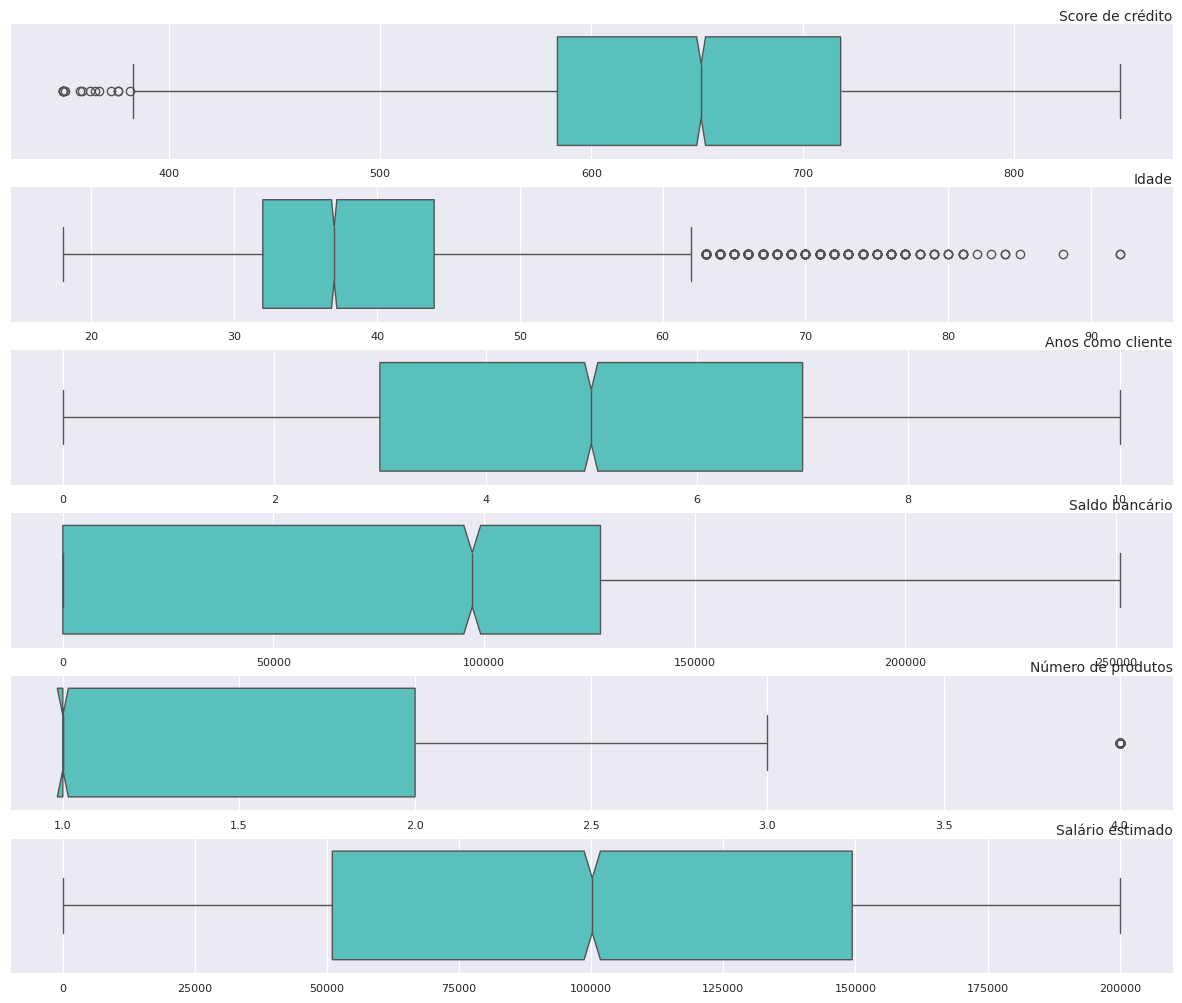

In [ ]:
# Função para geração de gráficos boxplot

def graf_boxplot(coluna, ax, title):
    '''
    Verifica a quantidade de valores únicos de coluna(s) específica(s)

    :param coluna: Column Dataframe
        Dataframe e coluna a ser analisado.
    :param ax: Axis
        Eixo, posição que o gráfico irá ocupar.
    :param title: str
        Título dado ao gráfico.
    '''
    sns.boxplot(data=coluna, ax=ax, notch=True,
                orient='h', color='mediumturquoise')
    ax.set(xlabel='', ylabel='')
    ax.tick_params(labelsize=8)
    ax.ticklabel_format(style='plain', axis='x')
    ax.set_title(title, loc='right', fontsize=10, pad=-10)


fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(
    nrows=6, ncols=1, figsize=(15, 10))

graf_boxplot(df['CreditScore'], ax1, 'Score de crédito')
graf_boxplot(df['Age'], ax2, 'Idade')
graf_boxplot(df['Tenure'], ax3, 'Anos como cliente')
graf_boxplot(df['Balance'], ax4, 'Saldo bancário')
graf_boxplot(df['NumOfProducts'], ax5, 'Número de produtos')
graf_boxplot(df['EstimatedSalary'], ax6, 'Salário estimado')

plt.subplots_adjust(top=1.9, bottom=0.95)
plt.show()

In [ ]:
# Geração dos limites inferior e superior das variáveis que apresentaram outliers

cols = ['CreditScore', 'Age', 'NumOfProducts']

for col in cols:
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)
    IIQ = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IIQ
    limite_superior = Q3 + 1.5 * IIQ
    print(f'\n{col.upper()}')
    print(f'Limite inferior: {limite_inferior}')
    print(f'Limite superior: {limite_superior}')


CREDITSCORE
Limite inferior: 383.0
Limite superior: 919.0

AGE
Limite inferior: 14.0
Limite superior: 62.0

NUMOFPRODUCTS
Limite inferior: -0.5
Limite superior: 3.5


In [ ]:
# Função para exibição dos valores únicos dos outliers

def valores_outliers (col, lim, sinal):
    '''
    Exibe os valores únicos dos outliers

    :param col: Column Dataframe
        Dataframe e coluna a ser analisado.
    :param lim: int
        Valor do limite inferior ou superior.
    :param sinal: str
        Símbolo de maior(>) ou menor(<).
    '''
    arr = np.array(df[col])
    if sinal == '>':
        val = arr[np.where(arr > lim)[0]]
    else:
        val = arr[np.where(arr < lim)[0]]
    print(f'\n{col.upper()}: {np.unique(val)}')

valores_outliers('CreditScore', 383, '<')
valores_outliers('Age', 62, '>')
valores_outliers('NumOfProducts', 3.5, '>')


CREDITSCORE: [350 351 358 359 363 365 367 373 376 382]

AGE: [63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 88
 92]

NUMOFPRODUCTS: [4]


Algumas variáveis independentes apresentaram alguns outliers como CreditScore (Score de crédito) onde há pontuações abaixo de 380, aproximadamente, Age (Idade) com casos entre 60 e pouco mais de 90 anos e NumOfProducts (Número de produtos) onde há um grupo de clientes com 4 produtos bancários. Estas situações não significam, necessariamente, que haja alguma inconsistência nos dados, mas sim que há casos que estão fora das orcorrências comuns identificadas no conjunto de dados, portanto seram mantidos.

2. Distribuição dos valores da váriavel dependente (target)

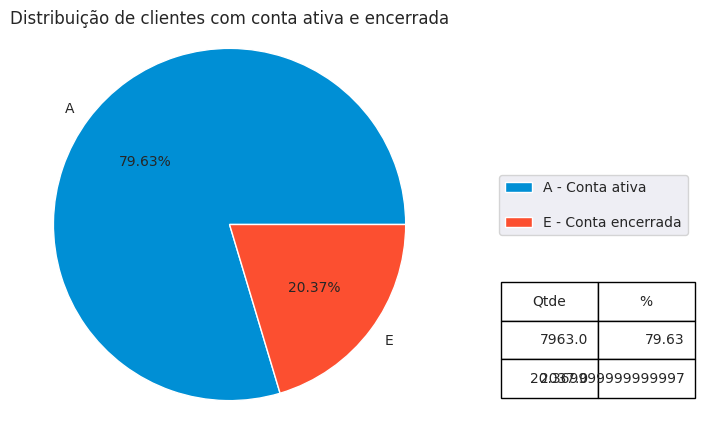

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

df_exited = df['Exited'].value_counts().reset_index()
df_exited.columns = ['Exited', 'Qtde']

df_exited['%'] = df_exited['Qtde'] / df_exited['Qtde'].sum() * 100

plt.figure(figsize=(5, 5))

plt.pie(
    df_exited['%'],
    labels=['A', 'E'],
    colors=['#008fd5', '#fc4f30'],
    autopct='%0.2f%%'
)

plt.legend(
    loc='right',
    labels=['A - Conta ativa', 'E - Conta encerrada'],
    labelspacing=1.5,
    bbox_to_anchor=(1.1, 0.1, 0.6, 0.9)
)

plt.title('Distribuição de clientes com conta ativa e encerrada')

cell_text = df_exited[['Qtde', '%']].values

table = plt.table(
    cellText=cell_text,
    colLabels=['Qtde', '%'],
    loc='bottom right',
    bbox=(1.2, 0.05, 0.5, 0.3)
)

table.auto_set_font_size(False)
table.set_fontsize(10)

plt.axis('equal')
plt.show()

Embora seja comum clientes fecharem contas bancárias, o atual percentual de 20,37% de perda de clientes (2037 contas) é um índice muito alto, observando o gráfico está se aproximando de 1/4 do total de contas que o banco já administrou.

3. Distribuição dos dados entre as variáveis independentes (features) e dependente (target)

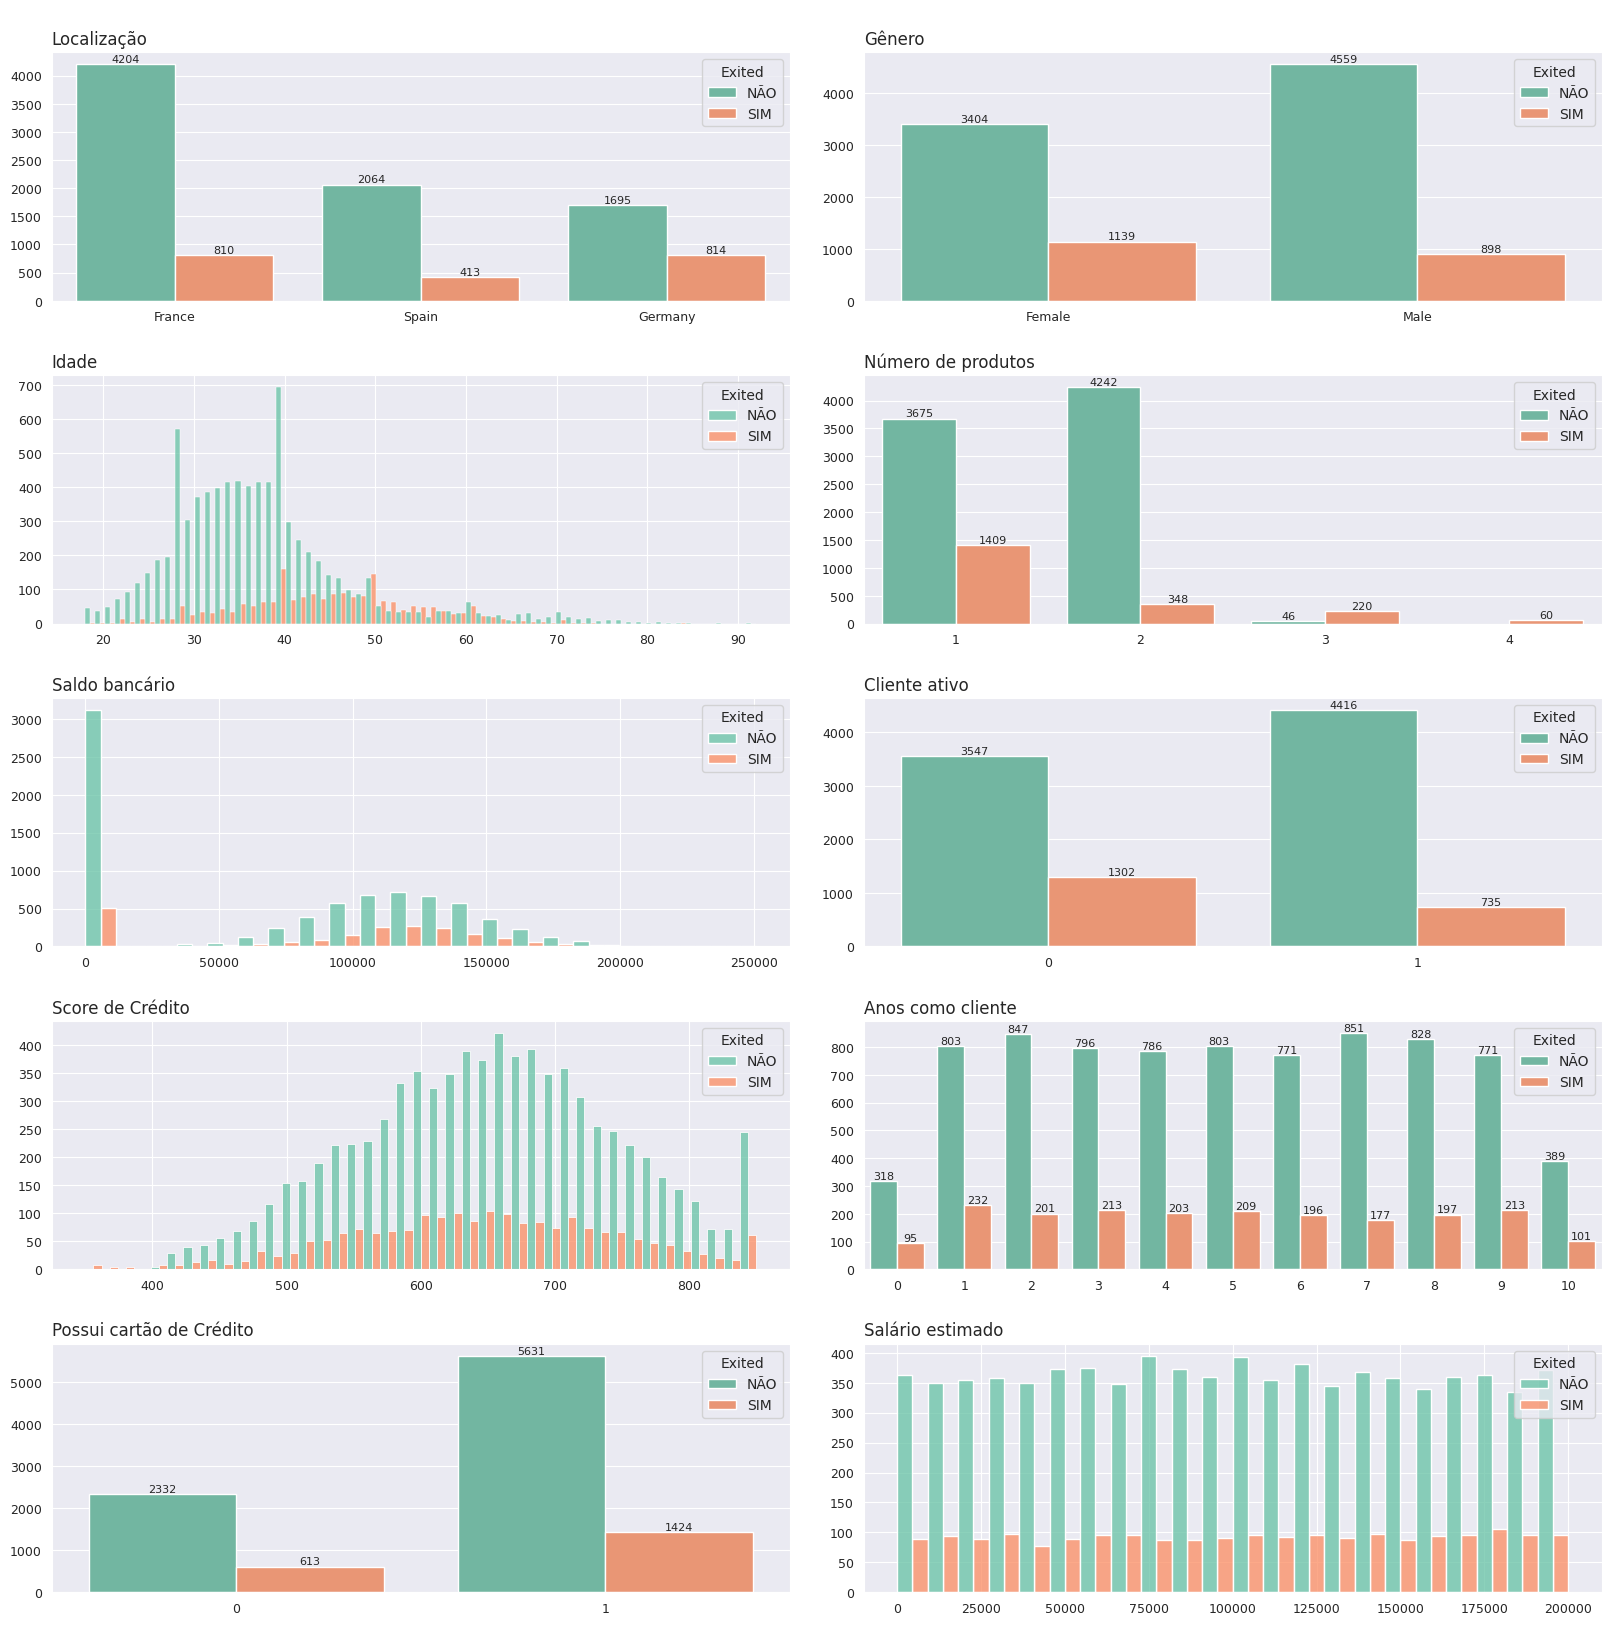

In [109]:
# Funções para gerar gráficos histplot e countplot

saida = df['Exited'].replace({0: 'NÃO', 1: 'SIM'})
hue_order = ['NÃO', 'SIM']


def graf_countplot(df, x, title, ax):
    '''
    Função para gerar gráficos countplot

    :param df: Dataframe
        Nome do dataframe.
    :param x: str
        Nome da coluna do dataframe.
    :param title: str
        Título dado ao gráfico.
    :param ax: Axis
        Eixo, posição que o gráfico irá ocupar.
    '''
    ax = sns.countplot(data=df, x=x, hue=saida, ax=ax,
                       hue_order=hue_order, palette='Set2')
    for container in ax.containers:
        ax.bar_label(container, size=8)
    ax.set(xlabel='', ylabel='')
    ax.set_title(title, loc='left')
    ax.tick_params(labelsize=9)


def graf_histplot(df, x, title, ax):
    '''
    Função para gerar gráficos histplot

    :param df: Dataframe
        Nome do dataframe.
    :param x: str
        Nome da coluna do dataframe.
    :param title: str
        Título dado ao gráfico.
    :param ax: Axis
        Eixo, posição que o gráfico irá ocupar.
    '''
    ax = sns.histplot(data=df, x=x, hue=saida, ax=ax,
                      hue_order=hue_order,  palette='Set2', multiple='dodge')
    ax.set(xlabel='', ylabel='')
    ax.set_title(title, loc='left')
    ax.tick_params(labelsize=9)


fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),
      (ax7, ax8), (ax9, ax10)) = plt.subplots(5, 2, figsize=(20, 20))


graf_countplot(df, 'Geography', '\nLocalização', ax1)
graf_countplot(df, 'Gender', '\nGênero', ax2)
graf_histplot(df, 'Age', '\nIdade', ax3)
graf_countplot(df, 'NumOfProducts', '\nNúmero de produtos', ax4)
graf_histplot(df, 'Balance', '\nSaldo bancário', ax5)
graf_countplot(df, 'IsActiveMember', '\nCliente ativo', ax6)
graf_histplot(df, 'CreditScore', '\nScore de Crédito', ax7)
graf_countplot(df, 'Tenure', '\nAnos como cliente', ax8)
graf_countplot(df, 'HasCrCard', '\nPossui cartão de Crédito', ax9)
graf_histplot(df, 'EstimatedSalary', '\nSalário estimado', ax10)

plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()

A localização dos clientes que mais encerraram suas contas está mais concentrada na França (France) e Alemanha (Germany), sendo que visualmente há quase um empate na quantidade, destaque que se comparado aos clientes que mantiveram a conta a Alemanha é o país onde mais estão ocorrendo perdas de clientes.
Os clientes do gênero feminino são os que mais fecharam suas contas, fica mais evidente quando comparado aos clientes que se mantiveram.
Por idade, clientes com 40 e 50 anos aproximadamente são os que mais encerraram suas contas diferente dos que a mantiveram com idades de 28 e 40 anos aproximadamente.
Geralmente clientes que possuem um único produto contratado são os que mais fecharam suas contas sendo que a maioria que manteve conta no banco possuem dois ou somente um produto contratado.
Clientes sem saldo bancário possuem uma grande representação no volume de clientes, sendo estes os que mais encerraram suas contas.
Clientes que não movimentaram suas contas, não ativos, são os que mais fecharam suas contas bancárias.
Nos gráficos de Score de Crédito, Anos como cliente, Possui cartão de Crédito e Salário estimado, a quantidade de clientes que encerraram a conta, visualmente, segue em proporções semelhantes aos que mantiveram a conta.

4. Correlação entre as variáveis

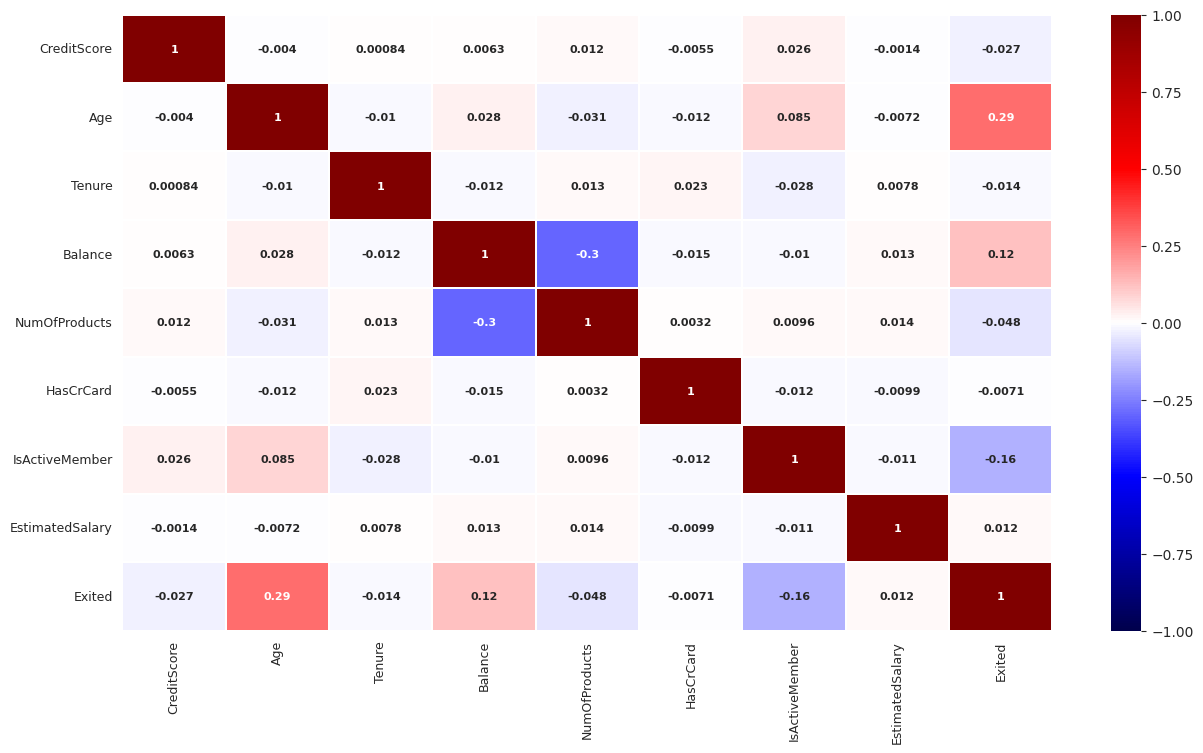

In [110]:
corr = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
           'IsActiveMember', 'EstimatedSalary', 'Exited']].corr(method='pearson')

plt.figure(figsize=(15, 8))
plot = sns.heatmap(data=corr, cmap='seismic', vmin=-1, linewidths=.2,
                   annot=True, annot_kws={'size': 8, 'fontweight': 'bold'})
plot.tick_params(labelsize=9)

A análise de correlação entre as variáveis independentes e a variável target (Exited) não identificou correlações fortemente significativas, positivas ou negativas. No entanto, é importante destacar que a falta de correlação forte não implica necessariamente que as variáveis não sejam importantes para a análise e elaboração de um modelo preditivo.

5. Preparação dos dados para aplicação no modelo preditivo

In [111]:
# Agrupar os pontos de score em faixas de pontuação

# very_low - de 0 a 300 pontos
# low - de 301 a 500 pontos
# good - de 501 a 700 pontos
# excellent - de 701 a 1000 pontos

faixa = [0, 301, 501, 701, df['CreditScore'].max()]
rotulos = ['very_low',
           'low',
           'good',
           'excellent']

df['CreditScore'] = pd.cut(df['CreditScore'], bins=faixa, labels=rotulos)
df = pd.DataFrame(df)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,good,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,good,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,good,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,good,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,excellent,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [112]:
# Agrupar idades numéricas em faixas etárias

# 18_24 - de 18 a 24 anos
# 25_34 - de 25 a 34 anos
# 35_44 - de 35 a 44 anos
# 45_54 - de 45 a 54 anos
# 55_64 - de 55 a 64 anos
# 65_More - maior ou igual a 65 anos

faixa = [17, 25, 35, 45, 55, 65, df['Age'].max()]
rotulos = ['18_24',
           '25_34',
           '35_44',
           '45_54',
           '55_64',
           '65_More']

df['Age'] = pd.cut(df['Age'], bins=faixa, labels=rotulos)
df = pd.DataFrame(df)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,good,France,Female,35_44,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,good,Spain,Female,35_44,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,good,France,Female,35_44,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,good,France,Female,35_44,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,excellent,Spain,Female,35_44,2,125510.82,1,1,1,79084.10,0


In [113]:
# Converter os saldos bancários em categorias

# 1 - se há saldo bancário
# 0 - se não há saldo bancário

maior_que_zero = lambda k: 1 if k > 0 else 0

df['Balance'] = df['Balance'].map(maior_que_zero)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,good,France,Female,35_44,2,0,1,1,1,101348.88,1
1,2,15647311,Hill,good,Spain,Female,35_44,1,1,1,0,1,112542.58,0
2,3,15619304,Onio,good,France,Female,35_44,8,1,3,1,0,113931.57,1
3,4,15701354,Boni,good,France,Female,35_44,1,0,2,0,0,93826.63,0
4,5,15737888,Mitchell,excellent,Spain,Female,35_44,2,1,1,1,1,79084.10,0


In [114]:
# Converter as quantidades de produtos em categorias

# 1_Product - possui 1 produto
# 2_Products - possui 2 produtos
# 3_MoreProducts - possui 3 ou mais produtos

dict = {'1': '1_Product', '2': '2_Products',
        '3': '3_MoreProducts', '4': '3_MoreProducts'}

for k in dict:
    df['NumOfProducts'] = [str(num).replace(k, dict[k])
                           for num in df['NumOfProducts']]

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,good,France,Female,35_44,2,0,1_Product,1,1,101348.88,1
1,2,15647311,Hill,good,Spain,Female,35_44,1,1,1_Product,0,1,112542.58,0
2,3,15619304,Onio,good,France,Female,35_44,8,1,3_MoreProducts,1,0,113931.57,1
3,4,15701354,Boni,good,France,Female,35_44,1,0,2_Products,0,0,93826.63,0
4,5,15737888,Mitchell,excellent,Spain,Female,35_44,2,1,1_Product,1,1,79084.10,0


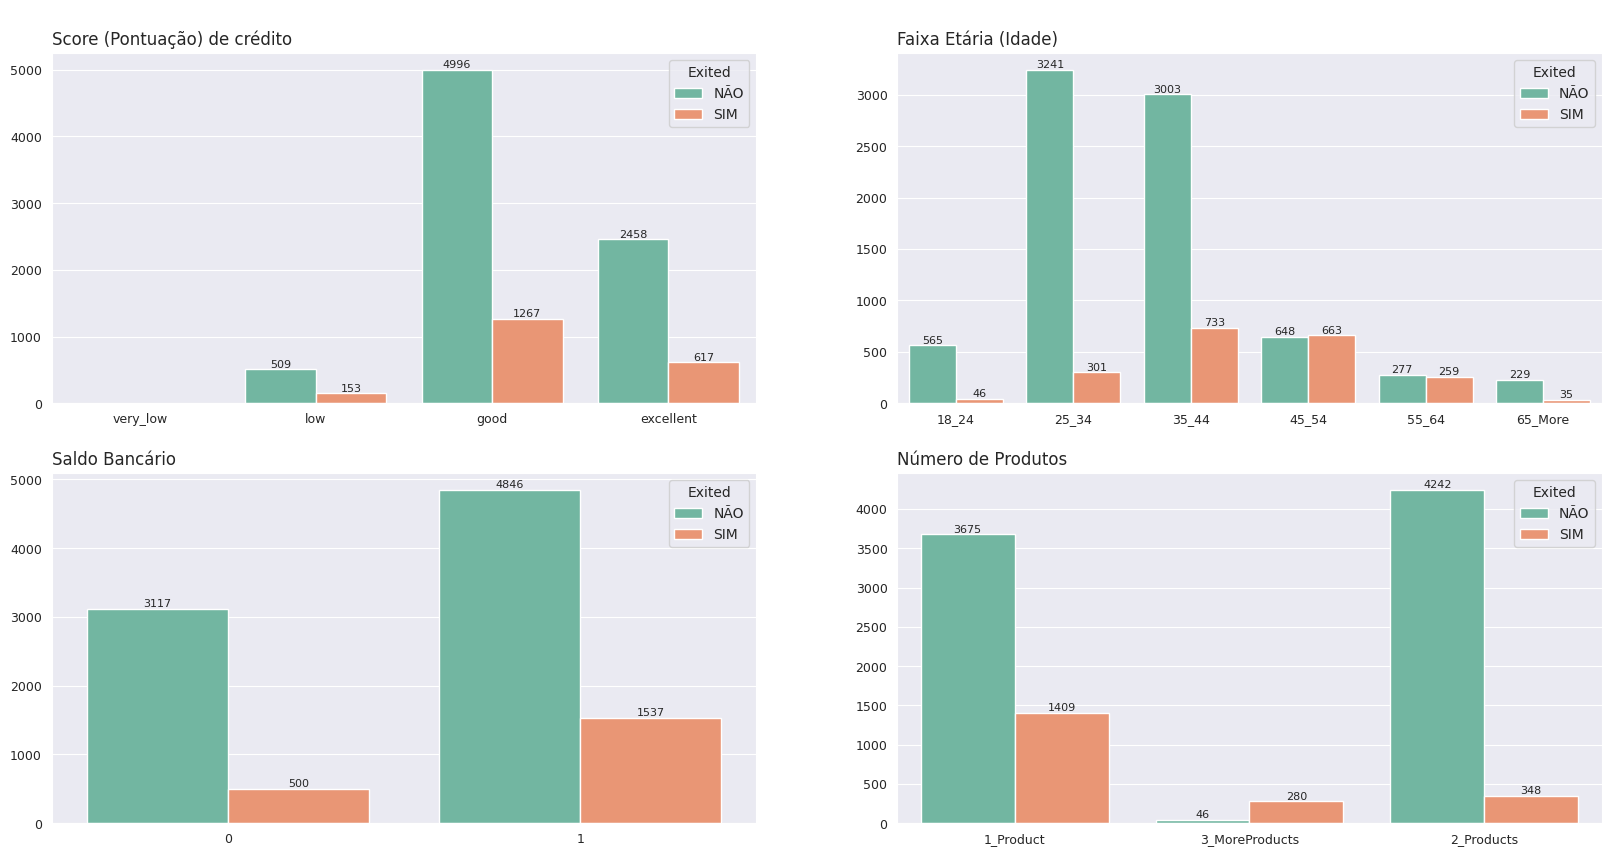

In [115]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 10))

graf_countplot(df, 'CreditScore', '\nScore (Pontuação) de crédito', ax1)
graf_countplot(df, 'Age', '\nFaixa Etária (Idade)', ax2)
graf_countplot(df, 'Balance', '\nSaldo Bancário', ax3)
graf_countplot(df, 'NumOfProducts', '\nNúmero de Produtos', ax4)

Variáveis como CreditScore (Pontuação de crédito), Age (Idade), Balance (Saldo bancário) e NumOfProducts (Número de produtos) apresentavam outliers, alguma ausência ou pouca variabilidade e representatividade nos seus dados, sendo assim, CreditScore que algumas pontuações eram consideradas outliers e Age que não contemplava todas as idades numéricas possíveis a partir dos 18 anos foram feitos agrupamentos por faixas de pontuação e faixas etárias respectivamente, Balance em que valores do saldo bancário foram convertidos em 0 (zero) que são contas vazias e 1 (um) que possuem algum saldo e NumOfProducts que inicialmente contia até 4 produtos e foram transformados em 3 categorias que representam 1 produto, 2 produtos e 3 ou mais produtos.

In [116]:
def transforme_onehotenconder(col, col_name, df):
    '''
    Função para transformando dos valores de colunas expecificas em categorias distintas

    :param col: Column Dataframe
        Dataframe e coluna a ser transformada.
    :param col_name: str
        Nome da coluna a ser transformada.
    :param names: list
        Lista com nomes para nomeação das colunas transformadas.
    :param df: Dataframe
        Nome do dataframe.
    return df: Dataframe
        Dataframe com as colunas transformadas.
    '''
    ohe = OneHotEncoder().fit_transform(col.values.reshape(-1, 1)).toarray()
    names = OneHotEncoder().fit(col.values.reshape(-1, 1)
                                ).get_feature_names_out([col_name])
    df_ohe = pd.DataFrame(ohe, columns=names)
    df = pd.concat([df, df_ohe], axis=1)
    return df


def transforme_labelenconder(col, name):
    '''
    Função para transformando dos valores de colunas expecificas em categorias distintas

    :param col: Column Dataframe
        Dataframe e coluna a ser transformada.
    :param name: str
        Nome da nova coluna do dataframe.
    return df: Dataframe
        Dataframe com as colunas transformadas.
    '''
    df[name] = LabelEncoder().fit_transform(col)
    return df


df = transforme_onehotenconder(df['CreditScore'], 'Score', df)
df = transforme_onehotenconder(df['Geography'], 'Geo', df)
df = transforme_onehotenconder(df['NumOfProducts'], 'Num', df)
df = transforme_onehotenconder(df['Age'], 'Age', df)
df = transforme_labelenconder(df['Gender'], 'Gender')

pd.set_option('display.max_columns', 26)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,...,Score_low,Geo_France,Geo_Germany,Geo_Spain,Num_1_Product,Num_2_Products,Num_3_MoreProducts,Age_18_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_More
0,1,15634602,Hargrave,good,France,0,35_44,2,0,1_Product,1,1,101348.88,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,15647311,Hill,good,Spain,0,35_44,1,1,1_Product,0,1,112542.58,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,15619304,Onio,good,France,0,35_44,8,1,3_MoreProducts,1,0,113931.57,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,15701354,Boni,good,France,0,35_44,1,0,2_Products,0,0,93826.63,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5,15737888,Mitchell,excellent,Spain,0,35_44,2,1,1_Product,1,1,79084.10,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


6. Padronização e separação (treino e teste) dos dados

As variáveis categóricas CreditScore (Pontuação de crédito), Geography (Localização), Age (Faixa etária) e NumOfProducts (Número de produtos) foram utilizadas para a criação variáveis binárias, cada uma se tornou uma categoria distinta, no caso de Gender (Gênero) suas duas categorias foram convertidas em 0 e 1 passando a ser uma variável binária.

In [161]:
# Separar X e y
X = df.drop(columns=['Exited'])
y = df['Exited']

# Converter todas as colunas categóricas em dummies
X = pd.get_dummies(X, drop_first=True)

# Padronizar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [162]:
for col in df.columns:
    if df[col].astype(str).str.contains('very_low', na=False).any():
        print(col)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   CreditScore         10000 non-null  category
 1   Age                 10000 non-null  category
 2   Tenure              10000 non-null  int64   
 3   Balance             10000 non-null  int64   
 4   NumOfProducts       0 non-null      float64 
 5   HasCrCard           10000 non-null  int64   
 6   IsActiveMember      10000 non-null  int64   
 7   EstimatedSalary     10000 non-null  float64 
 8   Exited              10000 non-null  int64   
 9   Score_excellent     10000 non-null  float64 
 10  Score_good          10000 non-null  float64 
 11  Score_low           10000 non-null  float64 
 12  Geo_France          10000 non-null  float64 
 13  Geo_Germany         10000 non-null  float64 
 14  Geo_Spain           10000 non-null  float64 
 15  Num_1_Product       10000 non-null  f

In [164]:
# Remover colunas que estão causando erro
df_modelo = df.drop(columns=['CreditScore', 'Age', 'NumOfProducts'], errors='ignore')

# Separar X e y
X = df_modelo.drop(columns=['Exited'])
y = df_modelo['Exited']

# Converter colunas booleanas para inteiro
X = X.astype(float)

# Padronizar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [171]:
# Padronizando os dados das features
std = StandardScaler().fit(X)
X = std.transform(X)

# Target, variável dependente
y = df['Exited'].copy()

# Definindo o percentual de dados para teste
perc = 0.2

# Definindo o random_state
seed = 42

# Separação dos dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=perc, random_state=seed)

print('\nQuantidade de dados divididos em treino e teste\n')
dict = {
    '': ['Treino', 'Teste'],
    'X': [X_train.shape, X_test.shape],
    'y': [y_train.shape, y_test.shape]
}

print(tabulate(dict, headers='keys', tablefmt='fancy_grid'))


Quantidade de dados divididos em treino e teste

╒════════╤════════════╤═════════╕
│        │ X          │ y       │
╞════════╪════════════╪═════════╡
│ Treino │ (8000, 23) │ (8000,) │
├────────┼────────────┼─────────┤
│ Teste  │ (2000, 23) │ (2000,) │
╘════════╧════════════╧═════════╛


7. Modelo preditivo: Regressão Logística

1. Busca pelos melhores parâmetros e treinamento do modelo

In [172]:
def busca_parametros(estimator, scoring, params, cv=5, verbose=1):
    '''
    Função para efetuar a busca dos melhores parâmetros

    :param estimator: str
        Estimador que será usado para treinar o modelo.
    :param scoring: str
        Métrica utilizada para avaliação do modelo.
    :param param_grid: dict
        Dicionário com uma combinação de valores de hiperparâmetros a serem testados.
    :param cv: int, default=5
        Número de 'folds' de divisão dos dados na validação cruzada.
    :param verbose: int, default=1
        Detalhes das mensagens impressas pela função.
    return:
        Objeto com os melhores parâmetros.
    '''
    return RandomizedSearchCV(estimator=estimator, scoring=scoring,
                              param_distributions=params, cv=cv, verbose=verbose)


# Definindo o dicionário de parâmetros de regressão logística
params = {
    'C': np.logspace(-1, 1),
    'class_weight': ['balanced'],
    'penalty': ['l1', 'l2'],
    'random_state': [42],
    'solver': ['saga', 'lbfgs'],
}

# Efetuando a busca pelos melhores parâmetros
search_cv_lr = busca_parametros(LogisticRegression(), 'recall', params)

# Treinamento do modelo
search_cv_lr.fit(X_train, y_train)


print('\nMelhores parâmetros\n')

for k, v in search_cv_lr.best_params_.items():
    print(f'{k} : {v}')

best_params = search_cv_lr.best_params_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores parâmetros

solver : saga
random_state : 42
penalty : l1
class_weight : balanced
C : 0.5963623316594643


2. Treinamento e predições do modelo

In [173]:
# Definição do modelo de regressão logística com os melhores parâmetros
logreg = LogisticRegression(**best_params)

# Treinamento do modelo
logreg.fit(X_train, y_train)

# Predição com os dados de teste
pred = logreg.predict(X_test)

3. Métricas de avaliação do modelo

In [174]:
def matriz_confusao(y_test, pred):
    '''
    Função para geração de visualização tabular da matriz de confusão

    :param y_test: série - pandas
        Série de dados de teste da variável target
    :param pred: array - numpy
        Array de dados previstos pelo modelo
    '''
    matrix = confusion_matrix(y_test, pred)
    arr = matrix.T
    dict = {
        '': ['0', '1'],
        '0': [i for i in arr[0]],
        '1': [i for i in arr[1]]
    }
    print('\nMatriz de confusão')
    print(tabulate(dict, headers='keys', tablefmt='fancy_grid'))

# Matriz de confusão, irá demonstrar visualmente as quantidades de
# previsões verdadeiras e que o modelo também identificou dessa forma
# os verdadeiros positivos (VP) e os verdadeiros negativos (VN) e
# também as previsões erradas, falsos positivos (FP) e negativos (FN).
# No caso de churn 1 = saída do banco e 0 = pemanência no banco

# ╒════╤══════╤═════╕
# │    │    0 │   1 │
# ╞════╪══════╪═════╡
# │  0 │  VP  │  FP │
# ├────┼──────┼─────┤
# │  1 │  FN  │  VN │
# ╘════╧══════╧═════╛


matriz_confusao(y_test, pred)


Matriz de confusão
╒════╤══════╤═════╕
│    │    0 │   1 │
╞════╪══════╪═════╡
│  0 │ 1244 │ 363 │
├────┼──────┼─────┤
│  1 │   88 │ 305 │
╘════╧══════╧═════╛


In [175]:
def pontuacao_modelo(y_test, pred):
    '''
    Função para geração da pontuação das métricas: Accuracy, Precision, Recall e F1-score

    :param y_test: série - pandas
        Série de dados de teste da variável target
    :param pred: array - numpy
        Array de dados previstos pelo modelo
    :return: dict
        Dicionário com a pontuação das métricas do modelo
    '''
    dict = {
        'Accuracy': [round(accuracy_score(y_test, pred)*100, 3)],
        'Precision': [round(precision_score(y_test, pred)*100, 3)],
        'Recall': [round(recall_score(y_test, pred)*100, 3)],
        'F1-score': [round(f1_score(y_test, pred)*100, 3)],
    }

    return dict

# - Accuracy (Acurácia): percentual de predições corretas em relação ao total de
#   predições feitas pelo modelo.
# - Precision (Precisão): percentual de acerto ao classificar uma predição em verdadeira
#   positiva em relação as predições verdadeiras e falsas positivas.
# - Recall (Sensibilidade ou Revocação): percentual de acerto ao classificar uma predição
#   em verdadeira positiva em relação as predições verdadeiras positivas e falsas negativas.
# - F1-score: média harmônica entre 'precision' e 'recall', fornecendo uma visão geral
#   do desempenho do modelo.


logreg_metrics = pontuacao_modelo(y_test, pred)

print(tabulate(logreg_metrics, headers='keys', tablefmt='fancy_grid'))

╒════════════╤═════════════╤══════════╤════════════╕
│   Accuracy │   Precision │   Recall │   F1-score │
╞════════════╪═════════════╪══════════╪════════════╡
│      77.45 │      45.659 │   77.608 │     57.493 │
╘════════════╧═════════════╧══════════╧════════════╛


8. Modelo preditivo: Decision Tree

1. Busca pelos melhores parâmetros e treinamento do modelo

2. Distribuição dos valores da váriavel dependente (target)

Passo 3 Avaliar o comportamento das variáveis O que esse comando faz

Esse comando avalia o comportamento da variável categórica Geography, mostrando quantos clientes existem em cada país.

In [ ]:
list(df["Geography"].unique())

['France', 'Spain', 'Germany']

In [ ]:
df["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


# 2. Contexto

Para fornecer uma visão completa e clara do seu projeto, é essencial contextualizá-lo adequadamente. Siga as etapas abaixo para garantir que você inclua todos os detalhes necessários:

1. Introduza a Empresa: nome e descrição da empresa, liste os principais serviços ou produtos que a empresa oferece.
2. Descreva Sua Função: quais são suas principais atividades e como elas se relacionam com o projeto?
3. Equipe: Se relevante, mencione a equipe com a qual você trabalha e como suas funções se interconectam com as suas.
4. Explique a Problemática: descreva o desafio e explique como esse problema está afetando a empresa.

----------



# 3. Submeta o projeto

- Após concluir o projeto conforme ensinado no curso de Projetos de Ciência de Dados 1 da FM2S, por favor, compartilhe o link do Google Colab com o projeto finalizado.

- Lembre-se de disponibilizar o Link Aberto para todos.

